## Load Packages

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid')

import jax
import numpyro

from cntmosaic.sim import (
	load_base_patterns,
	load_age_distribution,
	make_contact_pattern,
	simulate_age
)

from cntmosaic.preprocess import make_data
from cntmosaic.models import BRCFine
from cntmosaic.visuals import plot_cint_matrix, plot_cint_marginal

## Load Synthetic Contact Patterns

To construct the simulation dataset, we will use the synthetic contact patterns provided by the [mixing-patterns](https://github.com/mobs-lab/mixing-patterns) project. The repository provides age stratified contact matrices for 35 countries, including 277 subregions for 8 countries. For more information regarding the project, refer to the paper by [Mistry et al. (2021)](https://doi.org/10.1038/s41467-020-20544-y).

The `load_contact_patterns` and `load_age_distribution` functions from the `sim` module of `cntmosaic` are utilty functions to load the contact patterns and age distribution data from the mixing-patterns project.

In [2]:
# Specify the path to the mixing-patterns repository
repo_path = '/Users/shozendan/Imperial/0_Research/mixing-patterns'

# print_available_countries(repo_path)
country = 'United_States'
level = 'country'

patterns = load_base_patterns(repo_path, country, level, symmetrise=True, smooth=True)
age_dist = load_age_distribution(repo_path, country, level)

The `plot_base_patterns` function can be used to visualize the base contact patterns for a given country/region.

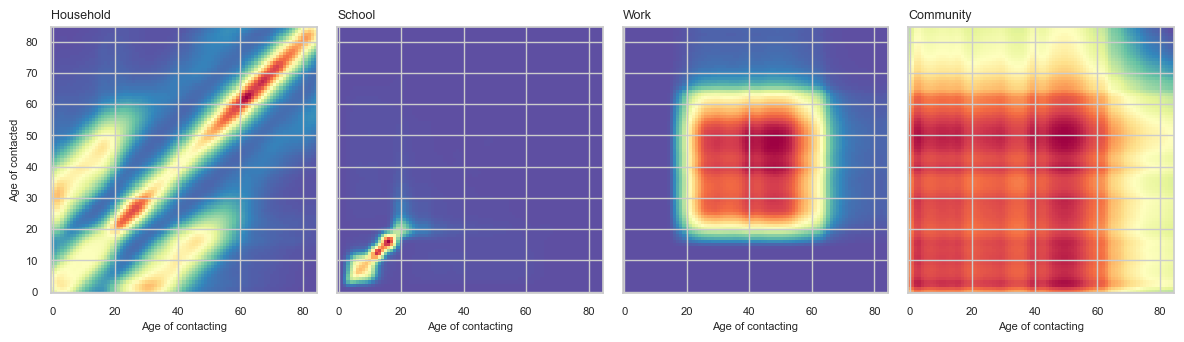

In [3]:
from cntmosaic.sim import plot_base_patterns

plot_base_patterns(patterns, figsize=(12,4), dpi=100)

We can also check the age distribution of the population.

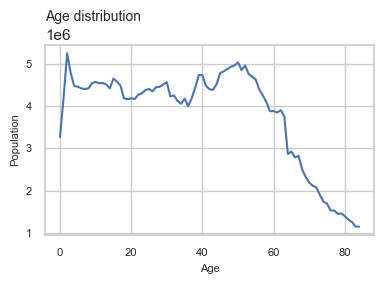

In [4]:
fig, ax = plt.subplots(figsize=(4,3), dpi=100)

ax.plot(age_dist.P.values)
ax.set_xlabel('Age', fontsize=8)
ax.set_ylabel('Population', fontsize=8)
ax.set_title('Age distribution', fontsize=10, loc='left')
ax.tick_params(axis='both', which='major', labelsize=8)
plt.tight_layout()
plt.show()

The `simulate_age` function can be used to generate simulated contact data and an evaluation dataset.

In [5]:
df_sample, df_eval = simulate_age(patterns, age_dist.P.values, dist='poisson')

`make_data` function can be used to prepare the data for the model.

In [6]:
df_train = make_data(df_sample, 'id')

The `BRCFine` class is a basic model designed for fine-age contact data. Bothe the age of participating individuals and the contacted individuals need to be reported in one-year age intervals.

In [7]:
model = BRCFine(df_train, age_dist.P.values, likelihood='negbin')

While full Bayesian inference is possible, due to the high-dimensional nature of the model, we will use stochastic variational inference (SVI) to estimate the model parameters.

In [8]:
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_value

init_values = {
  'baseline': -model.log_P.mean(),
  'hsgp_scale': 0.1,
  'hsgp_lengthscale': 1.0,
}

prng_key = jax.random.PRNGKey(0)
guide = AutoNormal(model.model, init_loc_fn=init_to_value(values=init_values))
model.run_inference_svi(prng_key, guide)

100%|██████████| 5000/5000 [00:22<00:00, 219.14it/s, init loss: 17463.7832, avg. loss [4751-5000]: 9660.8038]


We can the sample from the predictive posterior to generate quantities of interest.

In [9]:
po_svi = model.posterior_predictive_svi(prng_key, guide, 2000)

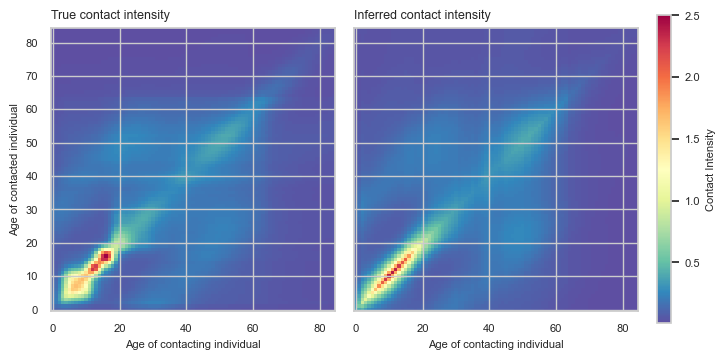

In [10]:
import matplotlib.gridspec as gridspec

# Create a custom gridspec
fig = plt.figure(figsize=(8, 4), dpi=100)
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)

# Create subplots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
cbar_ax = fig.add_subplot(gs[2])

# Example data
A = df_eval['age_part'].max() + 1
cint_true = df_eval['cint'].values.reshape(A, A, order='F')
cint_pred = np.exp(po_svi['log_cint']).mean(axis=0)

# Determine common scale
vmin = min(cint_true.min(), cint_pred.min())
vmax = max(cint_true.max(), cint_pred.max())

im0 = plot_cint_matrix(ax0, cint_true, title='True contact intensity', vmin=vmin, vmax=vmax)
im1 = plot_cint_matrix(ax1, cint_pred, title='Inferred contact intensity', ylabel=False, vmin=vmin, vmax=vmax)

# Add color bar to its dedicated axis
cbar = fig.colorbar(im1, cax=cbar_ax, orientation='vertical')
cbar.set_label('Contact Intensity', fontsize=8)
cbar.ax.tick_params(labelsize=8)

plt.show()

In [20]:
log_cint_qnt = np.quantile(po_svi['log_cint'], [0.025, 0.5, 0.975], axis=0)
cint_qnt = np.exp(log_cint_qnt)

cint_true = df_eval['cint'].values.reshape(A, A, order='F')

cint_lb = cint_qnt[0]
cint_med = cint_qnt[1]
cint_ub = cint_qnt[2]

# Compute the root mean squared error
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(cint_true, cint_med)
print(f'RMSE: {rmse:.3f}')

# Compute the coverage of the 95% credible interval
coverage = np.mean((cint_lb <= cint_true) & (cint_true <= cint_ub))
print(f'Coverage: {coverage:.3f}')

RMSE: 0.044
Coverage: 0.534


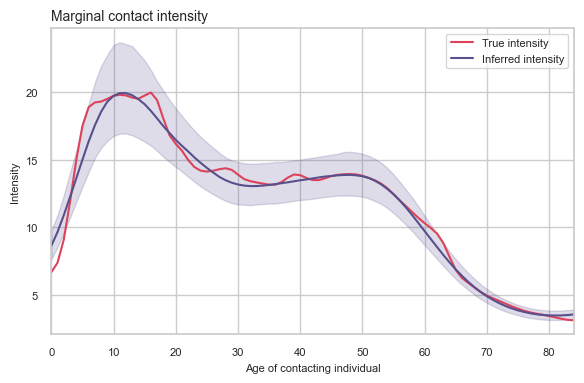

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=100)

po_mcint = np.exp(po_svi['log_cint']).sum(axis=2)
po_mcint = np.quantile(po_mcint, [0.025, 0.5, 0.975], axis=0)
mcint_true = df_eval.groupby('age_part')['cint'].sum().values
mcint_pred = po_mcint[1]
mcint_pred_lb = po_mcint[0]
mcint_pred_ub = po_mcint[2]

plot_cint_marginal(ax, mcint_true, label='True intensity')
plot_cint_marginal(ax, mcint_pred, mcint_pred_lb, mcint_pred_ub, color='#58508d', label='Inferred intensity')

ax.set_title('Marginal contact intensity', fontsize=10, loc='left')
ax.set_xlim(0, len(mcint_true)-1)
ax.legend(fontsize=8)

fig.tight_layout()

In [23]:
# Compute the root mean squared error
rmse = root_mean_squared_error(mcint_true, mcint_pred)
print(f'RMSE: {rmse:.3f}')

# Compute the coverage of the 95% credible interval
coverage = np.mean((mcint_pred_lb <= mcint_true) & (mcint_true <= mcint_pred_ub))
print(f'Coverage: {coverage:.3f}')

RMSE: 0.720
Coverage: 0.918
